 # Эксперимент 1: Разведочный анализ данных (EDA) и Feature Engineering

**Цель:** Анализ транзакций H&M для выбора архитектуры рекомендательной системы и подготовки данных.
** Данные:** * **Исходный источник:** Датасет H&M Personalized Fashion Recommendations.
* **Входные файлы (отфильтрованные выборки):**
  * `transactions_mini.csv` — транзакции пользователей за последний активный месяц (срез актуального сезонного спроса).
  * `articles_mini.csv` — очищенный справочник «живых» товаров (без учета архивных позиций).

**Основные выводы:**
1. **Очистка от архива:** ~75 000 неактивных товаров (без продаж >30 дней) удалены для ускорения вычислений и повышения актуальности выдачи.
2. **Длинный хвост:** 31.3% каталога покупались 1-2 раза (лишь 1.2% продаж).Классический ML их проигнорирует, поэтому для них я буду использовать Content-based (NLP) подход.
3. **Холодный старт пользователей:** 23.4% клиентов совершили всего 1 покупку. Для них матричные алгоритмы не сработают — в API будет настроена **Fallback-стратегия** (популярное с учетом цены).
4. **Сегментация Basic / Fashion:** Каталог разделен на базовые вещи (~8%) и модные (~92%). Это позволит рекомендовать базу как дополнение, а моду — через поиск похожих.
5. **Бизнес-фильтр по цене:** Товары разбиты на корзины Budget, Medium и Premium. API не будет советовать премиальные вещи пользователям с бюджетной историей.
6. **Учет сезонности:** Топ продаж подтверждает актуальный осенний спрос — модель защищена от рекомендаций не в сезон.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc


In [3]:
articles = pd.read_csv('/Users/apple/Desktop/aiee/Abdulmanov_KSBO-13-24_group_1/data_for_project/articles.csv', dtype={'article_id': str})
print(articles.head())

   article_id  product_code          prod_name  product_type_no  \
0  0108775015        108775          Strap top              253   
1  0108775044        108775          Strap top              253   
2  0108775051        108775      Strap top (1)              253   
3  0110065001        110065  OP T-shirt (Idro)              306   
4  0110065002        110065  OP T-shirt (Idro)              306   

  product_type_name  product_group_name  graphical_appearance_no  \
0          Vest top  Garment Upper body                  1010016   
1          Vest top  Garment Upper body                  1010016   
2          Vest top  Garment Upper body                  1010017   
3               Bra           Underwear                  1010016   
4               Bra           Underwear                  1010016   

  graphical_appearance_name  colour_group_code colour_group_name  ...  \
0                     Solid                  9             Black  ...   
1                     Solid               

In [4]:
customers = pd.read_csv('/Users/apple/Desktop/aiee/Abdulmanov_KSBO-13-24_group_1/data_for_project/customers.csv', dtype={'article_id': str})
print(customers.head())

                                         customer_id   FN  Active  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...  NaN     NaN   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...  NaN     NaN   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...  NaN     NaN   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...  NaN     NaN   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...  1.0     1.0   

  club_member_status fashion_news_frequency   age  \
0             ACTIVE                   NONE  49.0   
1             ACTIVE                   NONE  25.0   
2             ACTIVE                   NONE  24.0   
3             ACTIVE                   NONE  54.0   
4             ACTIVE              Regularly  52.0   

                                         postal_code  
0  52043ee2162cf5aa7ee79974281641c6f11a68d276429a...  
1  2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...  
2  64f17e6a330a85798e4998f62d0930d14db8db1c054af6...  
3  5d36574f52495e81f019b680c843c443bd343d5ca5b

In [5]:
input_path = '/Users/apple/Desktop/aiee/Abdulmanov_KSBO-13-24_group_1/data_for_project/transactions_train.csv'
output_path = '/Users/apple/Desktop/aiee/Abdulmanov_KSBO-13-24_group_1/project/data/transactions_mini.csv'

rows_before = sum(1 for line in open(input_path)) - 1

last_date = pd.read_csv(input_path, usecols=['t_dat'])['t_dat'].max()
cutoff = pd.to_datetime(last_date) - pd.Timedelta(days=30)

chunks = pd.read_csv(input_path, chunksize=1_000_000, 
                     dtype={'article_id': str, 'price': 'float32'}, 
                     parse_dates=['t_dat'])

transactions_mini = pd.concat([c[c['t_dat'] >= cutoff] for c in chunks])

transactions_mini.to_csv(output_path, index=False)

rows_after = len(transactions_mini)
print(f"Было строк в исходном файле: {rows_before}")
print(f"Стало строк (за последние 30 дней): {rows_after}")
print("Датасет transactions_mini загружен в папку data.")

Было строк в исходном файле: 31788324
Стало строк (за последние 30 дней): 1155933
Датасет transactions_mini загружен в папку data.


In [6]:
print("Пропуски в транзакциях:\n", transactions_mini.isnull().sum())

duplicates = transactions_mini.duplicated().sum()
print(f"Полных дубликатов строк: {duplicates}")

print(f"Уникальных пользователей: {transactions_mini['customer_id'].nunique()}")
print(f"Уникальных товаров: {transactions_mini['article_id'].nunique()}")

Пропуски в транзакциях:
 t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64
Полных дубликатов строк: 101837
Уникальных пользователей: 250619
Уникальных товаров: 29237


Одна покупка — несколько штук: Покупатель мог купить сразу 3 одинаковых белых футболки. В базе данных это часто записывается как три отдельные строки с одинаковым временем, ID пользователя и ID товара. Иногда при выгрузке данных транзакции из разных магазинов или онлайн-каналов могут дублироваться. С одной стороны, они показывают силу предпочтения (если человек купил 5 одинаковых вещей, значит, они ему очень нужны). С другой стороны, для большинства простых моделей (коллаборативная фильтрация) нам важно само событие интереса, а лишние строки просто замедляют обучение. Я решил удалить, чтобы модель не переобучалась на одних и тех же парах.

In [7]:
transactions_mini = transactions_mini.drop_duplicates()

print(f"Осталось строк после удаления дубликатов: {len(transactions_mini)}")

Осталось строк после удаления дубликатов: 1054096


In [8]:
top_10_articles = transactions_mini['article_id'].value_counts().head(10)
top_articles_info = top_10_articles.to_frame().merge(articles, on='article_id', how='left')
print("Топ-10 продаваемых товаров:")
print(top_articles_info[['article_id', 'prod_name', 'product_type_name']])

Топ-10 продаваемых товаров:
   article_id                  prod_name product_type_name
0  0751471001        Pluto RW slacks (1)          Trousers
1  0915529003                    Liliana           Sweater
2  0915526001                  Nika vest           Sweater
3  0918292001  STRONG HW seamless tights   Leggings/Tights
4  0751471043        Pluto RW slacks (1)          Trousers
5  0706016001   Jade HW Skinny Denim TRS          Trousers
6  0898694001      Jasba jersey  shacket            Blazer
7  0863595006          Baraboom throw-on          Cardigan
8  0448509014  Perrie Slim Mom Denim TRS          Trousers
9  0909370001          FF PI Haley dress             Dress


In [9]:
all_articles = set(articles['article_id'])
sold_articles = set(transactions_mini['article_id'])
never_sold = all_articles - sold_articles

print(f"Товаров в каталоге: {len(all_articles)}")
print(f"Товаров продано за месяц: {len(sold_articles)}")
print(f"Товаров с 0 продаж: {len(never_sold)}")

Товаров в каталоге: 105542
Товаров продано за месяц: 29237
Товаров с 0 продаж: 76305


In [10]:
path = '/Users/apple/Desktop/aiee/Abdulmanov_KSBO-13-24_group_1/data_for_project/transactions_train.csv'

item_dates = pd.read_csv(path, 
                         usecols=['article_id', 't_dat'], 
                         dtype={'article_id': str}, 
                         parse_dates=['t_dat'])

lifecycle = item_dates.groupby('article_id')['t_dat'].agg(['min', 'max'])
lifecycle.columns = ['first_sale', 'last_sale']

one_month_ago = lifecycle['last_sale'].max() - pd.Timedelta(days=30)

def classify_item(row):
    if row['last_sale'] < one_month_ago:
        return 'Archive'  
    if row['first_sale'] >= one_month_ago:
        return 'New'
    return 'Active'

lifecycle['status'] = lifecycle.apply(classify_item, axis=1)

print(lifecycle['status'].value_counts())

del item_dates
gc.collect()

status
Archive    75310
Active     25341
New         3896
Name: count, dtype: int64


0

Уберем из articles все товары со статусом архив(товары которые перестали продавать)

In [11]:
articles_with_status = articles.merge(lifecycle[['status']], on='article_id', how='left')

articles_mini = articles_with_status[articles_with_status['status'].isin(['Active', 'New'])].copy()

articles_mini['detail_desc'] = articles_mini['detail_desc'].fillna('No description')

print(f"Размер articles_mini: {len(articles_mini)} товаров.")
articles_mini.to_csv('/Users/apple/Desktop/aiee/Abdulmanov_KSBO-13-24_group_1/project/data/articles_mini.csv', index=False)

Размер articles_mini: 29237 товаров.


In [12]:
transactions_mini = transactions_mini[transactions_mini['article_id'].isin(articles_mini['article_id'])]

print(f"Строк в транзакциях после чистки архива: {len(transactions_mini)}")

Строк в транзакциях после чистки архива: 1054096


In [13]:
user_transaction_counts = transactions_mini.groupby('customer_id').size()

one_time_buyers_count = (user_transaction_counts == 1).sum()
total_users = len(user_transaction_counts)
one_time_buyers_share = (one_time_buyers_count / total_users) * 100

print(f"Всего уникальных покупателей за месяц: {total_users}")
print(f"Из них совершили только 1 покупку: {one_time_buyers_count} ({one_time_buyers_share:.1f}%)")

Всего уникальных покупателей за месяц: 250619
Из них совершили только 1 покупку: 58665 (23.4%)


garment_group_name
Jersey Fancy         168682
Knitwear             128539
Jersey Basic         128377
Under-, Nightwear    109422
Trousers             108743
Blouses               85700
Accessories           58000
Trousers Denim        50483
Dresses Ladies        45112
Outdoor               32773
Name: count, dtype: int64


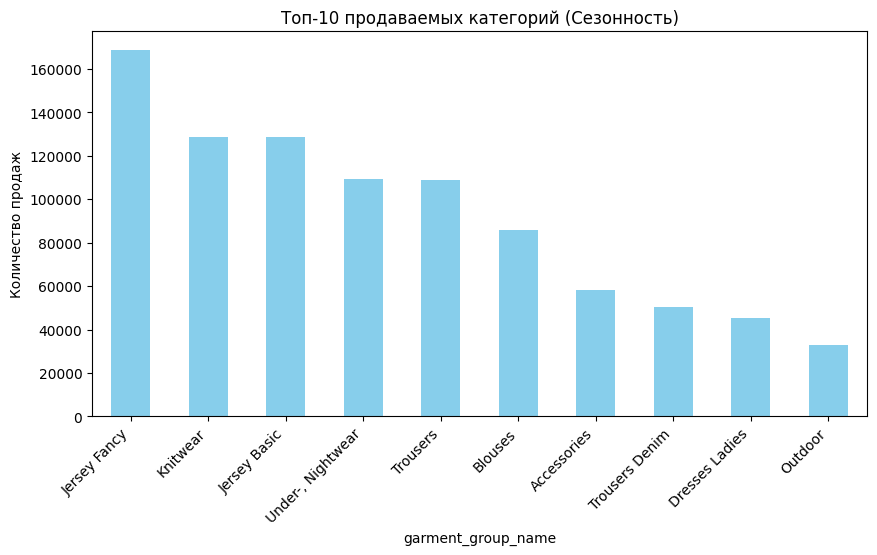

In [14]:
sold_items_with_categories = transactions_mini[['article_id']].merge(
    articles_mini[['article_id', 'product_group_name', 'garment_group_name']], 
    on='article_id', 
    how='inner'
)

top_garments = sold_items_with_categories['garment_group_name'].value_counts().head(10)
print(top_garments)

top_garments.plot(kind='bar', figsize=(10, 5), color='skyblue', title='Топ-10 продаваемых категорий (Сезонность)')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45, ha='right')
plt.savefig('../artifacts/plots/Top_10_Selling_Categories.png', bbox_inches='tight')
plt.show()

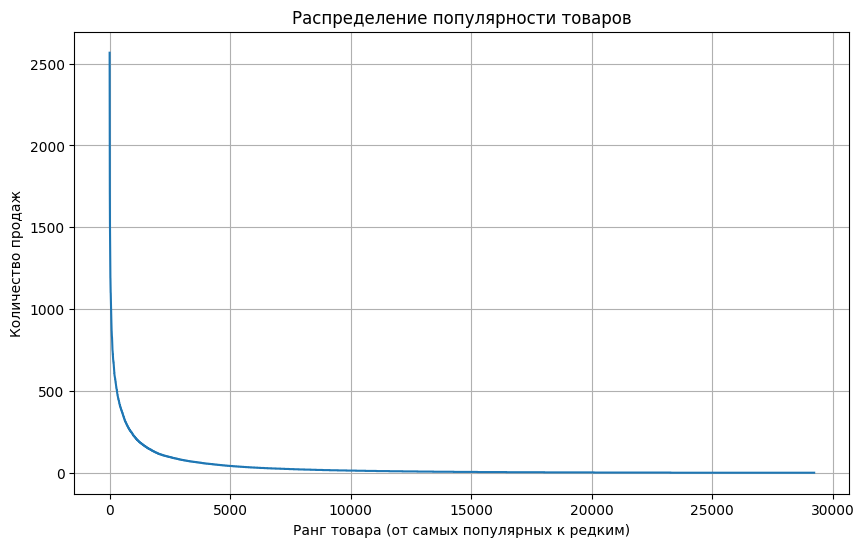

In [15]:
item_popularity = transactions_mini['article_id'].value_counts().values

plt.figure(figsize=(10, 6))
plt.plot(item_popularity)
plt.title('Распределение популярности товаров')
plt.xlabel('Ранг товара (от самых популярных к редким)')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.savefig('../artifacts/plots/Distribution_of_product_popularity.png', bbox_inches='tight')
plt.show()

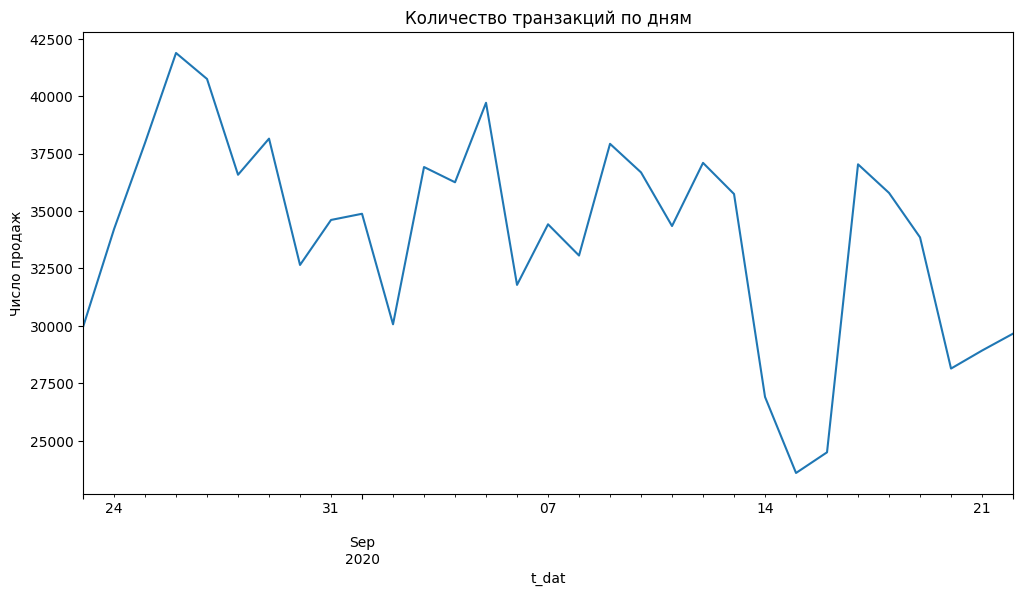

In [16]:
plt.figure(figsize=(12, 6))
transactions_mini.groupby('t_dat').size().plot()
plt.title('Количество транзакций по дням')
plt.ylabel('Число продаж')
plt.savefig('../artifacts/plots/Number_of_transactions_by_day.png', bbox_inches='tight')
plt.show()

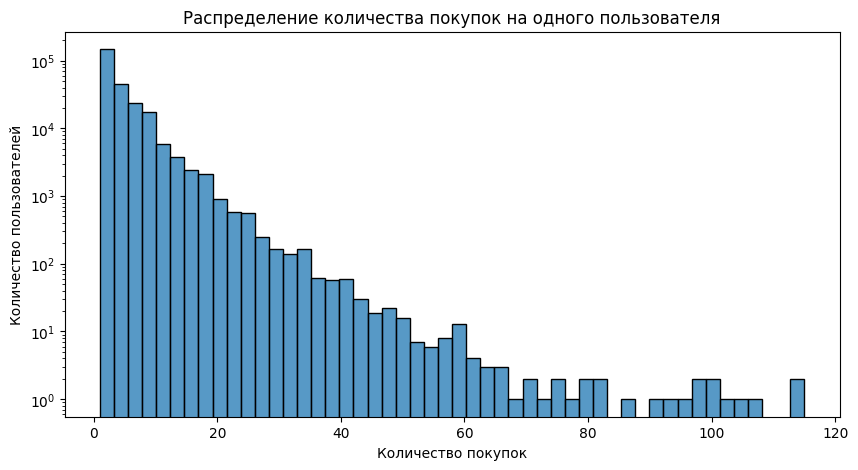

In [17]:
user_activity = transactions_mini.groupby('customer_id')['article_id'].count()

plt.figure(figsize=(10, 5))
sns.histplot(user_activity, bins=50, kde=False)
plt.title('Распределение количества покупок на одного пользователя')
plt.xlabel('Количество покупок')
plt.ylabel('Количество пользователей')
plt.yscale('log')
plt.savefig('../artifacts/plots/Distribution_of_purchases_per_user.png', bbox_inches='tight')
plt.show()

In [18]:
top_100_share = transactions_mini['article_id'].value_counts(normalize=True).head(100).sum()
print(f"Топ-100 товаров генерируют {top_100_share:.2%} всех продаж")

Топ-100 товаров генерируют 11.18% всех продаж


In [19]:
repeat_customers = transactions_mini.groupby(['customer_id', 'article_id']).size()
print(f"Доля повторных покупок одного и того же товара: {(repeat_customers > 1).mean():.2%}")

Доля повторных покупок одного и того же товара: 3.13%


In [20]:
basic_keywords = ['basic', 'pack', 'multipack', 'essential', 'tights', 'socks', 'underwear']

def check_text_base(row):
    text = str(row['prod_name']).lower() + " " + str(row['detail_desc']).lower()
    return any(word in text for word in basic_keywords)

quantity_per_order = transactions_mini.groupby(['customer_id', 'article_id', 't_dat']).size().reset_index(name='qty')
avg_qty = quantity_per_order.groupby('article_id')['qty'].mean()

articles_mini['text_is_basic'] = articles_mini.apply(check_text_base, axis=1)

articles_mini['behavior_is_basic'] = articles_mini['article_id'].map(avg_qty) > 1.3

def classify_item(row):
    if row['text_is_basic'] or row['behavior_is_basic']:
        return 'Basic'
    return 'Fashion'

articles_mini['item_type'] = articles_mini.apply(classify_item, axis=1)

articles_mini.drop(columns=['text_is_basic', 'behavior_is_basic'], inplace=True)

print("Распределение типов товаров:")
print(articles_mini['item_type'].value_counts())
print("\nПримеры базовых товаров:")
print(articles_mini[articles_mini['item_type'] == 'Basic']['prod_name'].head(10))

Распределение типов товаров:
item_type
Fashion    27280
Basic       1957
Name: count, dtype: int64

Примеры базовых товаров:
8        Shape Up 30 den 1p Tights
9         Support 40 den 1p Tights
10               200 den 1p Tights
27    Control Top 50 den 1p Tights
39          Mama 100 den 1p Tights
40                Dorian l/s basic
41                Dorian l/s basic
44                Dorian l/s basic
45                Dorian l/s basic
46        Tanktop body white 3PACK
Name: prod_name, dtype: str


In [21]:
sales_per_item = transactions_mini['article_id'].value_counts()
rare_items = sales_per_item[sales_per_item <= 2]

total_items_sold = len(sales_per_item)
rare_items_count = len(rare_items)

total_transactions = sales_per_item.sum()
rare_items_sales = rare_items.sum()

catalog_share = (rare_items_count / total_items_sold) * 100
sales_share = (rare_items_sales / total_transactions) * 100

print(f"Всеготоваров продано: {total_items_sold}")
print(f"товаров купили 1 или 2 раза: {rare_items_count} товаров")
print(catalog_share)
print(sales_share)

Всеготоваров продано: 29237
товаров купили 1 или 2 раза: 9150 товаров
31.295960597872558
1.1702918899227395


Всего товаров продано за месяц: 29237. Из них купили всего 1 или 2 раза: 9150 товаров. Это составляет 31.3% от всего ассортимента, но приносят они всего 1.2% от общего числа продаж. Эти цифры показывают классический эффект «Длинного хвоста», когда огромная часть ассортимента почти не продается. Для стандартной математической модели эти 9150 товаров просто «невидимы», так как одной-двух покупок недостаточно для поиска закономерностей. Если оставить всё как есть, алгоритм будет советовать всем только одни и те же популярные хиты, полностью игнорируя нишевые вещи и новинки. Поэтому необходимо использовать контентный подход (NLP). Нейросеть будет анализировать текстовые описания этих редких товаров и рекомендовать их по смыслу текста, обходя проблему нехватки данных о продажах.

In [22]:
item_prices = transactions_mini.groupby('article_id')['price'].median().reset_index()

articles_mini = articles_mini.merge(item_prices, on='article_id', how='left')

articles_mini['price'] = articles_mini['price'].fillna(articles_mini['price'].median())

articles_mini['price_segment'] = pd.qcut(
    articles_mini['price'], 
    q=3, 
    labels=['Budget', 'Medium', 'Premium']
)

print("Распределение товаров по ценовым сегментам:")
print(articles_mini['price_segment'].value_counts())

print("\nГраницы сегментов (в у.е. датасета):")
print(articles_mini.groupby('price_segment')['price'].agg(['min', 'max', 'median']))

Распределение товаров по ценовым сегментам:
price_segment
Budget     12083
Premium     9539
Medium      7615
Name: count, dtype: int64

Границы сегментов (в у.е. датасета):
                    min       max    median
price_segment                              
Budget         0.000729  0.016932  0.013186
Medium         0.016932  0.030492  0.025407
Premium        0.030492  0.506780  0.042356


In [23]:
active_users = transactions_mini['customer_id'].unique()
customers_mini = customers[customers['customer_id'].isin(active_users)].copy()
customers_mini.to_csv('../data/customers_mini.csv', index=False)

print(f"Всего клиентов в H&M: {len(customers)}")
print(f"Активных клиентов (в нашем срезе): {len(customers_mini)}")

Всего клиентов в H&M: 1371980
Активных клиентов (в нашем срезе): 250619


In [24]:
print(customers_mini['age'].describe())


count    249410.000000
mean         35.223002
std          13.965226
min          16.000000
25%          24.000000
50%          30.000000
75%          48.000000
max          99.000000
Name: age, dtype: float64


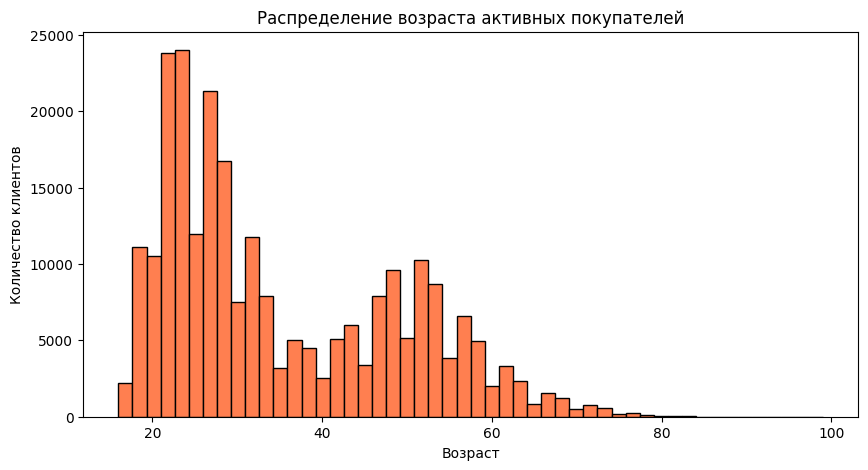

In [25]:
plt.figure(figsize=(10, 5))
customers_mini['age'].plot(kind='hist', bins=50, color='coral', edgecolor='black')
plt.title('Распределение возраста активных покупателей')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.savefig('../artifacts/plots/Age_distribution_of_buyers.png', bbox_inches='tight')
plt.show()

In [26]:
bins = [15, 24, 34, 49, 100]
labels = ['16-24', '25-34', '35-49', '50+']

customers_mini['age_group'] = pd.cut(customers_mini['age'], bins=bins, labels=labels)

age_distribution = customers_mini['age_group'].value_counts(normalize=True) * 100
print(age_distribution.round(1).astype(str) + '%')

age_group
25-34    31.0%
16-24    28.7%
50+      21.4%
35-49    18.9%
Name: proportion, dtype: str


In [27]:
club_status = customers_mini['club_member_status'].value_counts(dropna=False, normalize=True) * 100
print(club_status.round(2).astype(str) + '%')

club_member_status
ACTIVE        98.37%
PRE-CREATE     1.46%
NaN            0.15%
LEFT CLUB      0.01%
Name: proportion, dtype: str


In [28]:
customers_mini['fashion_news_frequency'] = customers_mini['fashion_news_frequency'].replace('None', 'NONE')
news_status = customers_mini['fashion_news_frequency'].value_counts(dropna=False, normalize=True) * 100
print(news_status.round(2).astype(str) + '%')

fashion_news_frequency
NONE         55.81%
Regularly    43.86%
NaN           0.31%
Monthly       0.03%
Name: proportion, dtype: str


In [29]:
transactions_mini.to_csv('../data/transactions_features.csv', index=False)
articles_mini.to_csv('../data/articles_features.csv', index=False)
customers_mini.to_csv('../data/customers_features.csv', index=False)